In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Matplotlib is building the font cache; this may take a moment.


In [5]:
df = pd.read_csv(r"C:\Users\RANJITH M KUMAR\OneDrive\Desktop\Used_Cars_Project\vehicles.csv")
df.head()


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [6]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

id                   0
url                  0
region               0
region_url           0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
image_url           68
description         70
county          426880
state                0
lat               6549
long              6549
posting_date        68
dtype: int64

In [12]:
df = df.dropna()


In [13]:
df.duplicated().sum()
df = df.drop_duplicates()


In [14]:
df.columns = df.columns.str.lower().str.replace(" ", "_")


In [16]:
df.columns


Index(['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer',
       'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status',
       'transmission', 'vin', 'drive', 'size', 'type', 'paint_color',
       'image_url', 'description', 'county', 'state', 'lat', 'long',
       'posting_date'],
      dtype='object')

In [17]:
df = df.dropna(subset=["price", "year", "odometer", "fuel", "transmission", "manufacturer"])


In [18]:
df = df.drop_duplicates()


In [19]:
df["price"] = df["price"].astype(float)
df["year"] = df["year"].astype(int)
df["odometer"] = df["odometer"].astype(float)


In [22]:
df.shape


(0, 26)

In [26]:
df = pd.read_csv(r"C:\Users\RANJITH M KUMAR\OneDrive\Desktop\Used_Cars_Project\vehicles.csv")

# Keep only useful columns (optional but cleaner)
df = df[["price", "year", "manufacturer", "odometer", "fuel", "transmission"]]

# Drop missing values
df = df.dropna()

# Remove unrealistic prices (Craigslist data has junk)
df = df[(df["price"] >= 500) & (df["price"] <= 200000)]

# Remove unrealistic odometer values
df = df[(df["odometer"] >= 0) & (df["odometer"] <= 500000)]

# Convert types
df["price"] = df["price"].astype(float)
df["year"] = df["year"].astype(int)
df["odometer"] = df["odometer"].astype(float)

df = df.drop_duplicates()

df.shape


(205554, 6)

In [25]:
df.shape
df["manufacturer"].value_counts().head()
df["price"].describe()


count    3.756190e+05
mean     8.378142e+04
std      1.298382e+07
min      1.000000e+00
25%      7.300000e+03
50%      1.549500e+04
75%      2.759000e+04
max      3.736929e+09
Name: price, dtype: float64

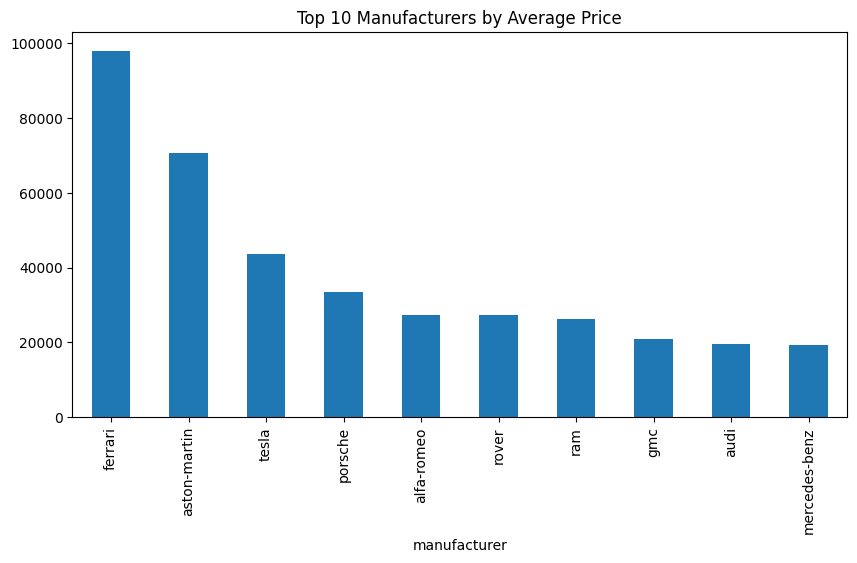

In [27]:
avg_price = df.groupby("manufacturer")["price"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
avg_price.plot(kind="bar")
plt.title("Top 10 Manufacturers by Average Price")
plt.show()


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\RANJITH M KUMAR\OneDrive\Desktop\Used_Cars_Project\vehicles.csv")

df = df[["price", "year", "manufacturer", "odometer", "fuel", "transmission"]]
df = df.dropna()

df = df[(df["price"] >= 500) & (df["price"] <= 200000)]
df = df[(df["odometer"] >= 0) & (df["odometer"] <= 500000)]

df["price"] = df["price"].astype(float)
df["year"] = df["year"].astype(int)
df["odometer"] = df["odometer"].astype(float)

df = df.drop_duplicates()


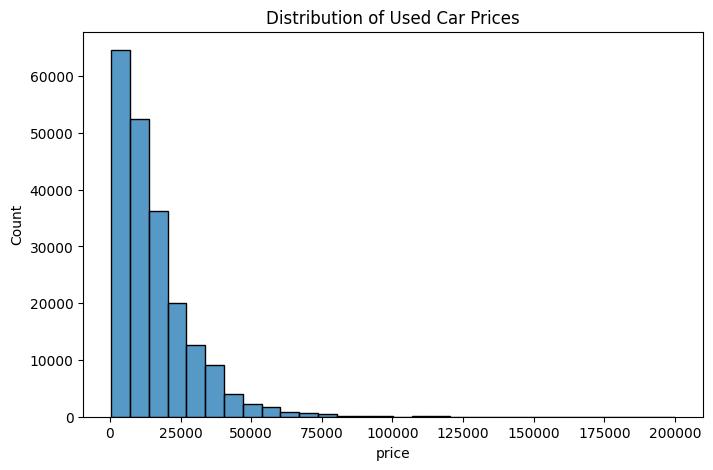

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=30)
plt.title("Distribution of Used Car Prices")
plt.show()


Insight:
Most used cars are priced in the lower to mid range, with few very expensive vehicles.

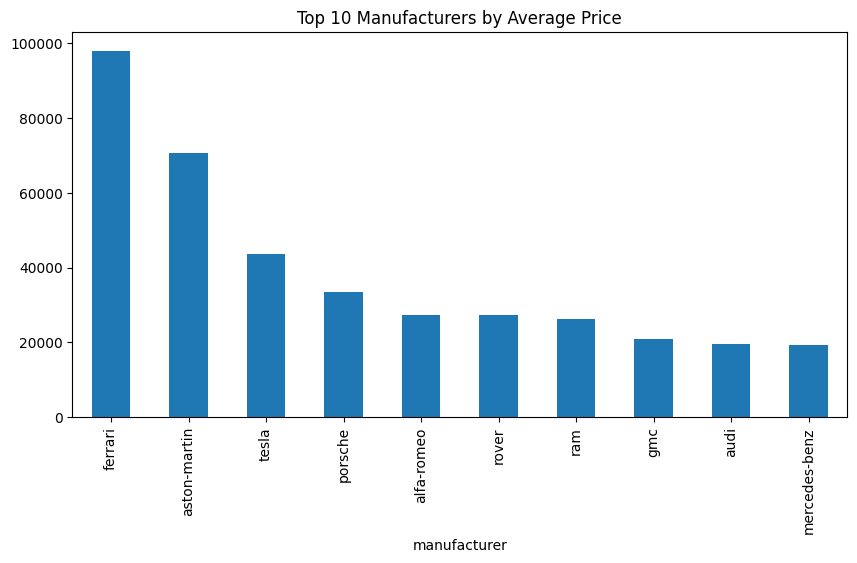

In [30]:
avg_price = df.groupby("manufacturer")["price"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
avg_price.plot(kind="bar")
plt.title("Top 10 Manufacturers by Average Price")
plt.show()

Insight:
Luxury manufacturers have higher average prices than economy brands.


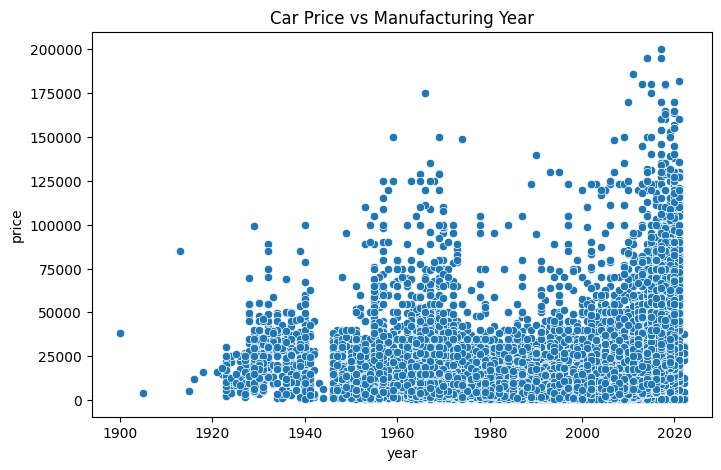

In [31]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="year", y="price")
plt.title("Car Price vs Manufacturing Year")
plt.show()


Insight:
Newer cars generally have higher prices due to depreciation over time.

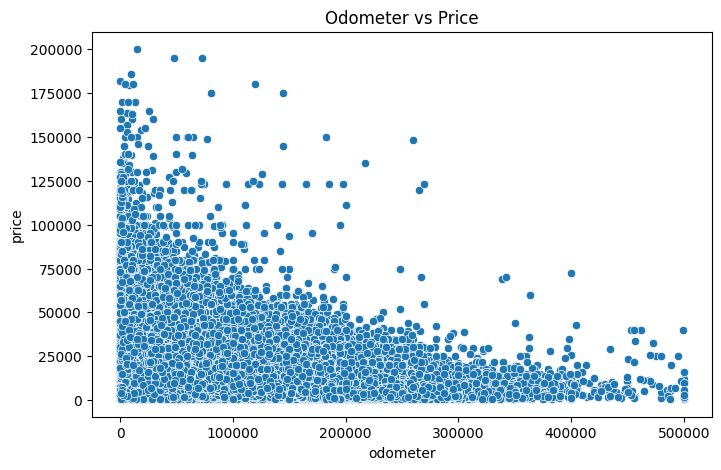

In [32]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="odometer", y="price")
plt.title("Odometer vs Price")
plt.show()


Insight:
Cars with higher mileage tend to have lower prices.

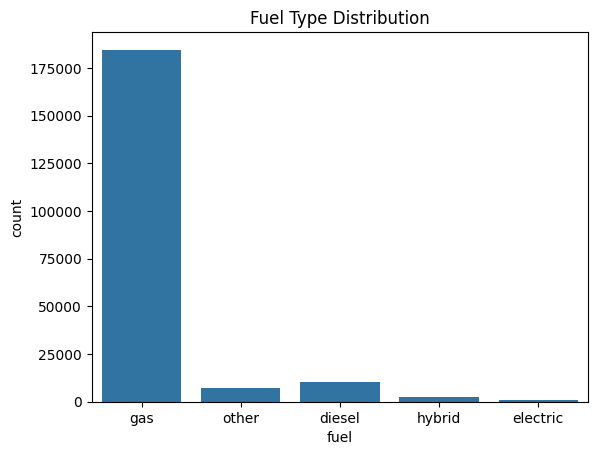

In [33]:
sns.countplot(x="fuel", data=df)
plt.title("Fuel Type Distribution")
plt.show()


Insight:
Gas vehicles dominate the used car market.

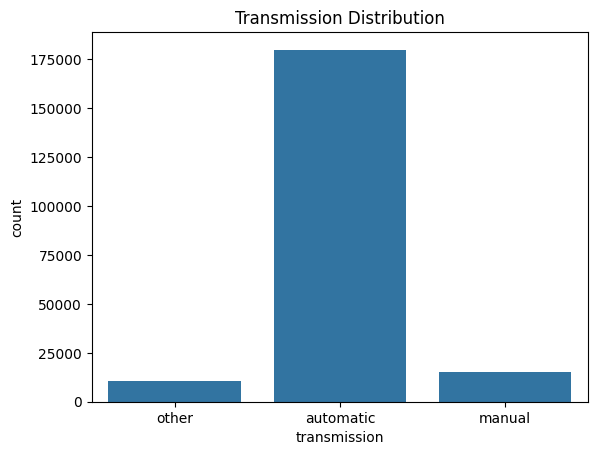

In [34]:
sns.countplot(x="transmission", data=df)
plt.title("Transmission Distribution")
plt.show()


Insight:
Automatic cars are more common than manual cars.

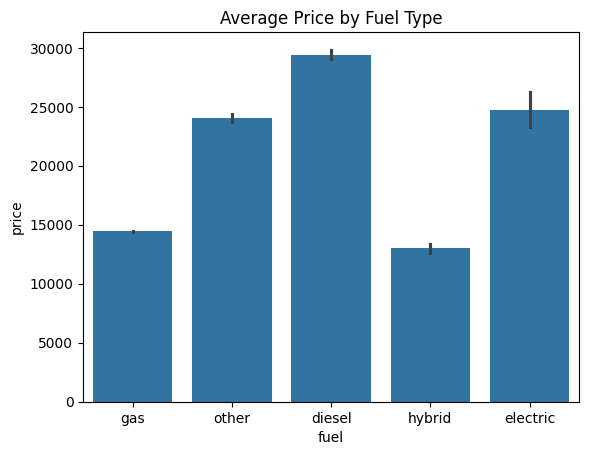

In [35]:
sns.barplot(x="fuel", y="price", data=df)
plt.title("Average Price by Fuel Type")
plt.show()


Insight:
Hybrid and electric cars tend to have higher average prices.

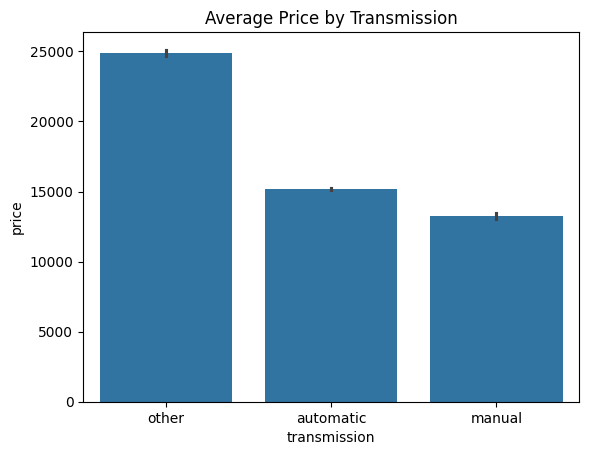

In [37]:
sns.barplot(x="transmission", y="price", data=df)
plt.title("Average Price by Transmission")
plt.show()


Insight:
Automatic transmission cars have higher average prices.

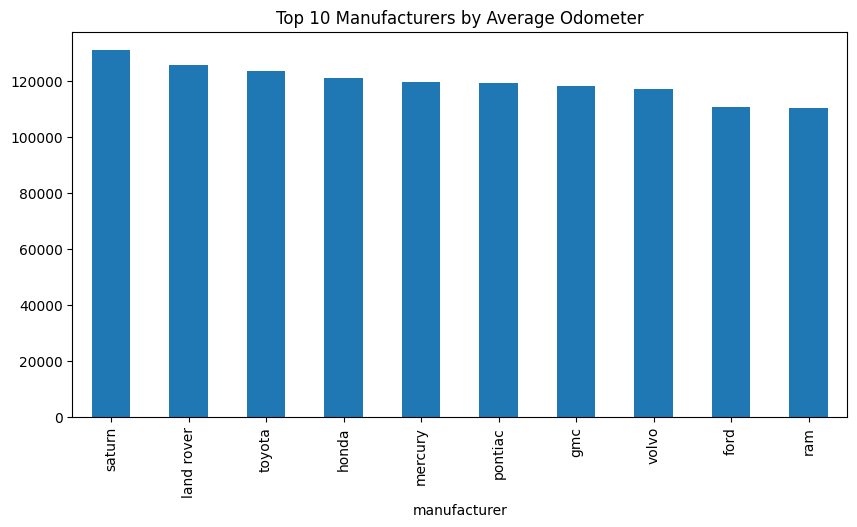

In [38]:
avg_odometer = df.groupby("manufacturer")["odometer"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
avg_odometer.plot(kind="bar")
plt.title("Top 10 Manufacturers by Average Odometer")
plt.show()


Insight:
Some manufacturers show higher average mileage, indicating longer usage.

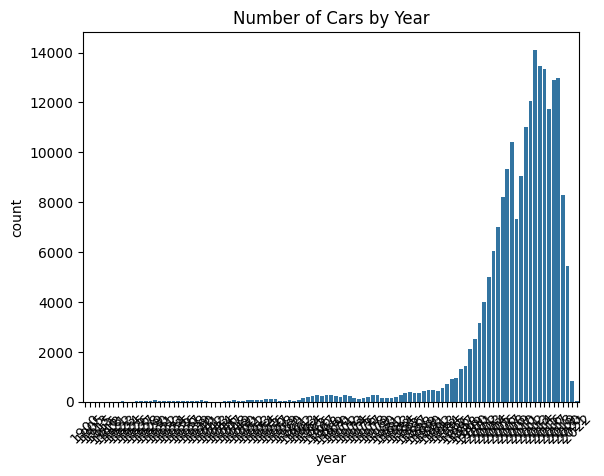

In [40]:
sns.countplot(x="year", data=df)
plt.xticks(rotation=45)
plt.title("Number of Cars by Year")
plt.show()


Insight:
More listings come from recent model years.